In [48]:
import pandas as pd

pd.set_option('display.max_rows', 20)

data = pd.read_excel('./../Data/mpd2023_web.xlsx', 'Full data')
data['GDP'] = data['gdppc'] * data['pop']
data

,countrycode,country,region,year,gdppc,pop,GDP
0,AFG,Afghanistan,South and South East Asia,1,NaN,NaN,NaN
1,AFG,Afghanistan,South and South East Asia,730,NaN,NaN,NaN
2,AFG,Afghanistan,South and South East Asia,1000,NaN,NaN,NaN
3,AFG,Afghanistan,South and South East Asia,1090,NaN,NaN,NaN
4,AFG,Afghanistan,South and South East Asia,1150,NaN,NaN,NaN
...,...,...,...,...,...,...,...
131139,ZWE,Zimbabwe,Sub Saharan Africa,2018,1900.199191,14096.56,2.678627e+07
131140,ZWE,Zimbabwe,Sub Saharan Africa,2019,1753.024449,14344.59,2.514642e+07
131141,ZWE,Zimbabwe,Sub Saharan Africa,2020,1585.972804,14614.82,2.317871e+07
131142,ZWE,Zimbabwe,Sub Saharan Africa,2021,1687.253154,14900.01,2.514009e+07


In [49]:
data_2015 = data[data['year'] == 2015]
data_2015

,countrycode,country,region,year,gdppc,pop,GDP
768,AFG,Afghanistan,South and South East Asia,2015,1928.000000,32564.00,6.278339e+07
1544,AGO,Angola,Sub Saharan Africa,2015,8319.567355,20353.70,1.693340e+08
2320,ALB,Albania,Eastern Europe,2015,10192.529180,2867.95,2.923166e+07
3096,ARE,United Arab Emirates,Middle East and North Africa,2015,71319.606113,9460.83,6.747427e+08
3872,ARG,Argentina,Latin America,2015,19423.666978,43779.41,8.503567e+08
...,...,...,...,...,...,...,...
128032,YEM,Yemen,Middle East and North Africa,2015,2820.617221,26698.17,7.530532e+07
128808,YUG,Former Yugoslavia,Eastern Europe,2015,14971.000000,21882.00,3.275954e+08
129584,ZAF,South Africa,Sub Saharan Africa,2015,12009.910457,57946.58,6.959332e+08
130360,ZMB,Zambia,Sub Saharan Africa,2015,3454.352707,16623.65,5.742395e+07


In [50]:
## import necessary libraries
import os

import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd

# !python3 --version
# !python3 -m pip --version

# %pip install mapclassify

In [51]:
# 使用 geopandas 读取本地 shapefile 文件
world = gpd.read_file('./../Data/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp')[['ADM0_A3', 'geometry']].to_crs('+proj=robin')

# 查看 world 数据集的列，包含国家信息
print(world.columns)

world.sample(5)

Index(['ADM0_A3', 'geometry'], dtype='object')


,ADM0_A3,geometry
94,VNM,"POLYGON ((9807745.197 1121555.952, 9885532.857..."
39,BLZ,"POLYGON ((-8302445.688 1904631.333, -8301184.5..."
77,LBN,"POLYGON ((3211977.132 3559163.514, 3188077.53 ..."
69,GNQ,"POLYGON ((911315.631 244263.855, 1065011.999 2..."
124,TUR,"MULTIPOLYGON (((3951044.885 3975060.707, 39116..."


In [52]:
cols = ['country', 'countrycode', 'gdppc']
data_2015_filtered = data_2015[cols]

# 查看结果
print(data_2015_filtered.head())

                   country countrycode         gdppc
768            Afghanistan         AFG   1928.000000
1544                Angola         AGO   8319.567355
2320               Albania         ALB  10192.529180
3096  United Arab Emirates         ARE  71319.606113
3872             Argentina         ARG  19423.666978


In [53]:
merged = world.merge(data_2015_filtered, left_on='ADM0_A3', right_on='countrycode')
merged.describe()

,gdppc
count,153.000000
mean,18096.255325
std,20445.517621
min,576.000000
25%,3464.037685
50%,12009.910457
75%,24285.141510
max,159800.188709


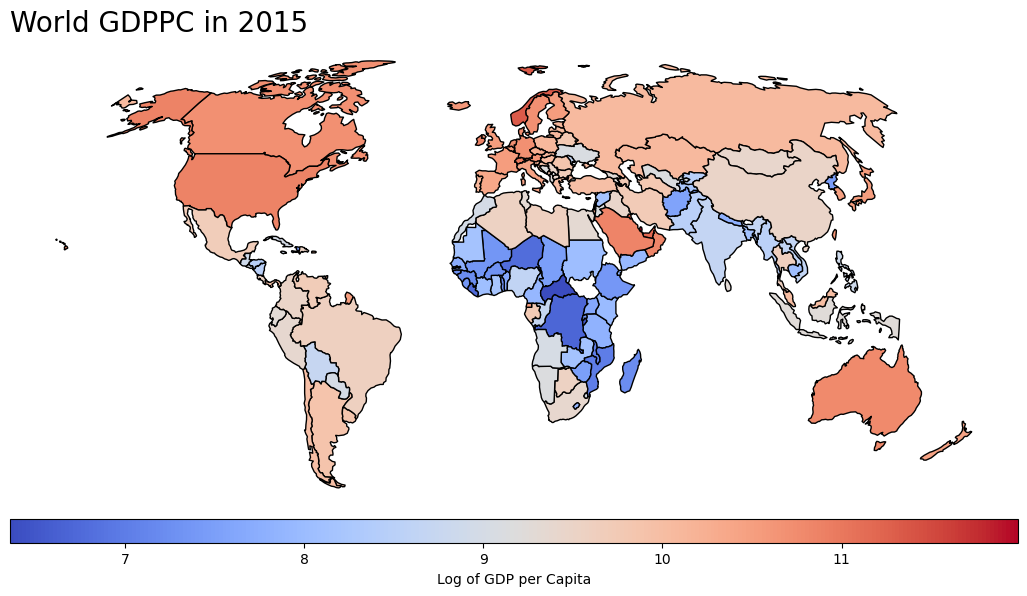

In [54]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable

# 假设 merged 是你的地理数据表格
# 取 'gdppc' 的对数值并创建新列 'log_gdppc'
merged['log_gdppc'] = np.log(merged['gdppc'] + 1)

# 使用 coolwarm colormap
new_cmap = plt.get_cmap('coolwarm', 256)  # 使用内置的 coolwarm colormap

# 创建图形和子图
fig_width = 3900 / 300  # 宽度为 1920 像素，300 DPI
fig_height = 2300 / 300  # 高度为 1080 像素，300 DPI

fig, ax = plt.subplots(figsize=(fig_width, fig_height))  # 设置合适的大小

# 使用 coolwarm colormap 进行绘图
merged.dropna().plot(
    column="log_gdppc",          # 使用 'log_gdppc' 列作为绘图数据
    cmap=new_cmap,               # 使用 coolwarm colormap
    ax=ax,                       # 绘制在指定的子图上
    scheme='equal_interval',     # 使用等间隔分类方法
    k=256,                        # 分成 12 类，以丰富颜色
    legend=False,                # 不显示图例，手动添加 colorbar
    edgecolor='black',           # 设置国家边界为黑色
    missing_kwds={               # 设置没有数据的国家颜色
        "color": "white"         # 将没有数据的国家设置为白色
    }
)

# 隐藏坐标轴上的数值
ax.set_xticks([])  # 隐藏x轴的刻度
ax.set_yticks([])  # 隐藏y轴的刻度
ax.spines[['top', 'right', 'bottom', 'left']].set_visible(False)  # 隐藏四边的轴线

# 添加 colorbar 在左下方并放在地图内部
divider = make_axes_locatable(ax)
cax = divider.append_axes("bottom", size="5%", pad=0.1)  # 在地图底部内部创建 colorbar 区域

# 创建 colorbar
sm = plt.cm.ScalarMappable(cmap=new_cmap, norm=plt.Normalize(vmin=merged['log_gdppc'].min(), vmax=merged['log_gdppc'].max()))
sm._A = []  # 必须要有这个属性才能生成 colorbar
cbar = plt.colorbar(sm, cax=cax, orientation="horizontal")  # 设置 colorbar 水平放置
cbar.set_label('Log of GDP per Capita')  # 设置 colorbar 的标签

# # 添加描述文字，说明白色区域代表没有数据
# description = 'The white areas represent countries with no data.'
# ax.annotate(description, xy=(0, 0.2), size=12, xycoords='figure fraction')

title ='World GDPPC in 2015'

# 设置标题
ax.set_title(title, fontdict={'fontsize': 20}, loc='left')

# 保存图像为 PNG，300 DPI 大小
plt.savefig('./../Notebooks/Images/World_Map_GDPPC.png', dpi=300, bbox_inches='tight')

# 显示图像
plt.show()


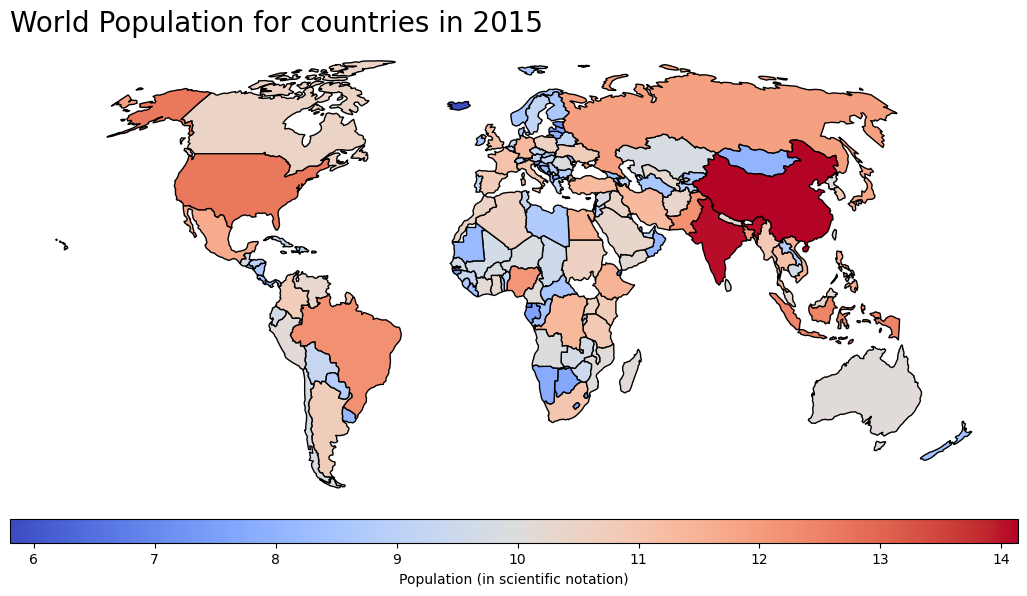

In [55]:
# POP

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable

cols = ['country', 'countrycode', 'pop']
data_2015_filtered_pop = data_2015[cols]
merged_pop = world.merge(data_2015_filtered_pop, left_on='ADM0_A3', right_on='countrycode')

# 假设 merged 是你的地理数据表格
# 取 'gdppc' 的对数值并创建新列 'log_gdppc'
merged_pop['log_pop'] = np.log(merged_pop['pop'] + 1)

# 使用 coolwarm colormap
new_cmap = plt.get_cmap('coolwarm', 256)  # 使用内置的 coolwarm colormap

# 创建图形和子图
fig_width = 3900 / 300  # 宽度为 1920 像素，300 DPI
fig_height = 2300 / 300  # 高度为 1080 像素，300 DPI

fig, ax = plt.subplots(figsize=(fig_width, fig_height))  # 设置合适的大小

# 使用 coolwarm colormap 进行绘图
ax_pop = merged_pop.dropna().plot(
    column="log_pop",          # 使用 'log_gdppc' 列作为绘图数据
    cmap=new_cmap,               # 使用 coolwarm colormap
    ax=ax,                       # 绘制在指定的子图上
    scheme='equal_interval',     # 使用等间隔分类方法
    k=256,                        # 分成 12 类，以丰富颜色
    legend=False,                # 不显示图例，手动添加 colorbar
    edgecolor='black',           # 设置国家边界为黑色
    missing_kwds={               # 设置没有数据的国家颜色
        "color": "white"         # 将没有数据的国家设置为白色
    }
)

# 隐藏坐标轴上的数值
ax.set_xticks([])  # 隐藏x轴的刻度
ax.set_yticks([])  # 隐藏y轴的刻度
ax.spines[['top', 'right', 'bottom', 'left']].set_visible(False)  # 隐藏四边的轴线

# 添加 colorbar 在左下方并放在地图内部
divider = make_axes_locatable(ax)
cax = divider.append_axes("bottom", size="5%", pad=0.1)  # 在地图底部内部创建 colorbar 区域

# 创建 colorbar
sm = plt.cm.ScalarMappable(cmap=new_cmap, norm=plt.Normalize(vmin=merged_pop['log_pop'].min(), vmax=merged_pop['log_pop'].max()))
sm._A = []  # 必须要有这个属性才能生成 colorbar
cbar = plt.colorbar(sm, cax=cax, orientation="horizontal")  # 设置 colorbar 水平放置
cbar.set_label('Population (in scientific notation)')  # 设置 colorbar 的标签

# # 添加描述文字，说明白色区域代表没有数据
# description = 'The white areas represent countries with no data.'
# ax.annotate(description, xy=(0.1, 0.1), size=12, xycoords='figure fraction')

title ='World Population for countries in 2015'

# 设置标题
ax.set_title(title, fontdict={'fontsize': 20}, loc='left')

# 保存图像为 PNG，300 DPI
plt.savefig('./../Notebooks/Images/World_Map_POP.png', dpi=300, bbox_inches='tight')

# 显示图像
plt.show()


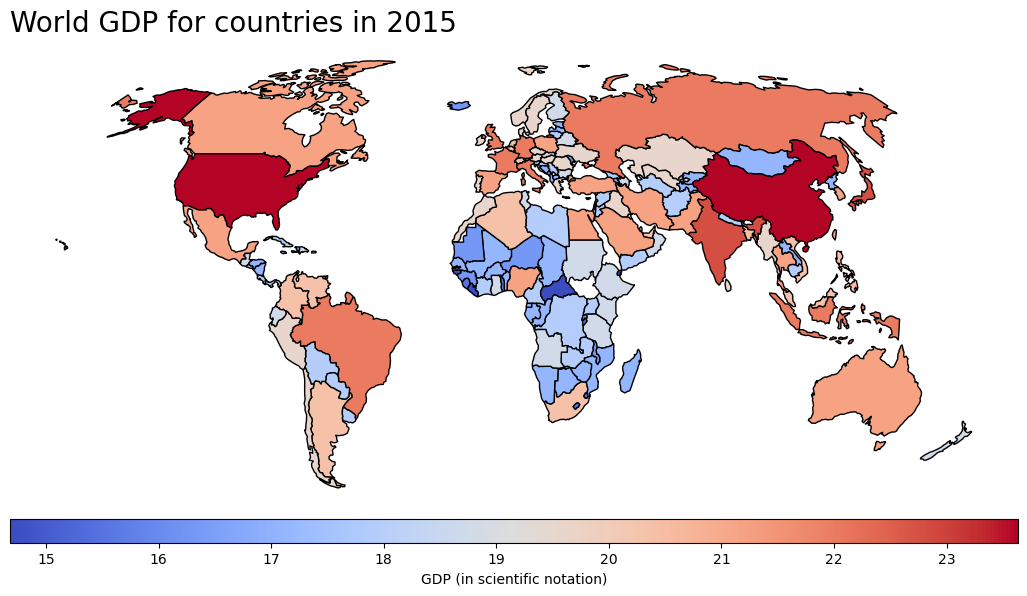

In [56]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import matplotlib.ticker as ticker

cols = ['country', 'countrycode', 'GDP']
data_2015_filtered_GDP = data_2015[cols]
merged_GDP = world.merge(data_2015_filtered_GDP, left_on='ADM0_A3', right_on='countrycode')

# 假设 merged 是你的地理数据表格
# 取 'gdppc' 的对数值并创建新列 'log_gdppc'
merged_GDP['log_GDP'] = np.log(merged_GDP['GDP'] + 1)

# 使用 coolwarm colormap
new_cmap = plt.get_cmap('coolwarm', 256)  # 使用内置的 coolwarm colormap

# 创建图形和子图
fig_width = 3900 / 300  # 宽度为 1920 像素，300 DPI
fig_height = 2300 / 300  # 高度为 1080 像素，300 DPI

fig, ax = plt.subplots(figsize=(fig_width, fig_height))  # 设置合适的大小

# 使用 coolwarm colormap 进行绘图
ax_pop = merged_GDP.dropna().plot(
    column="log_GDP",          # 使用 'log_gdppc' 列作为绘图数据
    cmap=new_cmap,               # 使用 coolwarm colormap
    ax=ax,                       # 绘制在指定的子图上
    scheme='equal_interval',     # 使用等间隔分类方法
    k=12,                        # 分成 12 类，以丰富颜色
    legend=False,                # 不显示图例，手动添加 colorbar
    edgecolor='black',           # 设置国家边界为黑色
    missing_kwds={               # 设置没有数据的国家颜色
        "color": "white"         # 将没有数据的国家设置为白色
    }
)

# 隐藏坐标轴上的数值
ax.set_xticks([])  # 隐藏x轴的刻度
ax.set_yticks([])  # 隐藏y轴的刻度
ax.spines[['top', 'right', 'bottom', 'left']].set_visible(False)  # 隐藏四边的轴线

# 添加 colorbar 在左下方并放在地图内部
divider = make_axes_locatable(ax)
cax = divider.append_axes("bottom", size="5%", pad=0.1)  # 在地图底部内部创建 colorbar 区域

# 创建 colorbar
sm = plt.cm.ScalarMappable(cmap=new_cmap, norm=plt.Normalize(vmin=merged_GDP['log_GDP'].min(), vmax=merged_GDP['log_GDP'].max()))
sm._A = []  # 必须要有这个属性才能生成 colorbar
cbar = plt.colorbar(sm, cax=cax, orientation="horizontal")  # 设置 colorbar 水平放置
cbar.set_label('GDP (in scientific notation)')  # 设置 colorbar 的标签

title ='World GDP for countries in 2015'

# 设置标题
ax.set_title(title, fontdict={'fontsize': 20}, loc='left')

# 保存图像为 PNG，300 DPI
plt.savefig('./../Notebooks/Images/World_Map_GDP.png', dpi=300, bbox_inches='tight') 

# 显示图像
plt.show()


In [57]:
cols = ['country', 'countrycode', 'gdppc', 'region']
# title = 'World Regional POP in {}'.format(year)

data_2015_filtered_gdppc_with_region = data_2015[cols]
merged_gdppc_region = world.merge(data_2015_filtered_gdppc_with_region, left_on='ADM0_A3', right_on='countrycode')
merged_gdppc_region.describe()

,gdppc
count,153.000000
mean,18096.255325
std,20445.517621
min,576.000000
25%,3464.037685
50%,12009.910457
75%,24285.141510
max,159800.188709


In [58]:
merged_gdppc_region

,ADM0_A3,geometry,country,countrycode,gdppc,region
0,TZA,"POLYGON ((3202917.599 -101604.324, 3218827.08 ...",U.R. of Tanzania: Mainland,TZA,2505.972429,Sub Saharan Africa
1,CAN,"MULTIPOLYGON (((-10141906.052 5223243.61, -101...",Canada,CAN,43761.527090,Western Offshoots
2,USA,"MULTIPOLYGON (((-10141906.052 5223243.61, -990...",United States,USA,52808.154135,Western Offshoots
3,KAZ,"POLYGON ((7202132.129 5245560.427, 7171298.638...",Kazakhstan,KAZ,23782.561755,Eastern Europe
4,UZB,"POLYGON ((4839886.346 4415250.374, 4735627.351...",Uzbekistan,UZB,9381.346864,Eastern Europe
...,...,...,...,...,...,...
148,BIH,"POLYGON ((1593151.087 4557266.27, 1513919.272 ...",Bosnia and Herzegovina,BIH,9639.477649,Eastern Europe
149,MKD,"POLYGON ((1924658.245 4522390.759, 1971241.692...",TFYR of Macedonia,MKD,12412.940671,Eastern Europe
150,SRB,"POLYGON ((1585599.314 4900532.058, 1585600.383...",Serbia,SRB,13013.853795,Eastern Europe
151,MNE,"POLYGON ((1723422.916 4550777.201, 1701164.495...",Montenegro,MNE,17249.000000,Eastern Europe


In [59]:
# 移除 country 列中值为 "Mongolia" 的行 because Mongolia is not belonged to south asia.
merged_gdppc_region = merged_gdppc_region[merged_gdppc_region['country'] != 'Mongolia']


In [60]:
merged_gdppc_region['geometry'] = merged_gdppc_region['geometry'].simplify(tolerance=0.001)
# 检查无效几何
invalid_geometries = merged_gdppc_region[~merged_gdppc_region.is_valid]
print(f"Found {len(invalid_geometries)} invalid geometries.")

# 使用 buffer(0) 修复无效的几何
merged_gdppc_region['geometry'] = merged_gdppc_region['geometry'].buffer(0)
merged_gdppc_region

Found 1 invalid geometries.


/opt/miniconda3/envs/AI_PS/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/opt/miniconda3/envs/AI_PS/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,ADM0_A3,geometry,country,countrycode,gdppc,region
0,TZA,"POLYGON ((3202917.599 -101604.324, 3218827.08 ...",U.R. of Tanzania: Mainland,TZA,2505.972429,Sub Saharan Africa
1,CAN,"MULTIPOLYGON (((-5208367.604 8233653.667, -510...",Canada,CAN,43761.527090,Western Offshoots
2,USA,"MULTIPOLYGON (((-10141906.052 5223243.61, -883...",United States,USA,52808.154135,Western Offshoots
3,KAZ,"POLYGON ((7202132.129 5245560.427, 7171298.638...",Kazakhstan,KAZ,23782.561755,Eastern Europe
4,UZB,"POLYGON ((4839886.346 4415250.374, 4735627.351...",Uzbekistan,UZB,9381.346864,Eastern Europe
...,...,...,...,...,...,...
148,BIH,"POLYGON ((1593151.087 4557266.27, 1513919.272 ...",Bosnia and Herzegovina,BIH,9639.477649,Eastern Europe
149,MKD,"POLYGON ((1924658.245 4522390.759, 1971241.692...",TFYR of Macedonia,MKD,12412.940671,Eastern Europe
150,SRB,"POLYGON ((1585599.314 4900532.058, 1585600.383...",Serbia,SRB,13013.853795,Eastern Europe
151,MNE,"POLYGON ((1723422.916 4550777.201, 1701164.495...",Montenegro,MNE,17249.000000,Eastern Europe


In [61]:
region_geometry_gdppc = merged_gdppc_region.dissolve(by='region')
region_geometry_gdppc

,geometry,ADM0_A3,country,countrycode,gdppc
region,,,,,
East Asia,"MULTIPOLYGON (((10128808.149 2119895.941, 1022...",PRK,D.P.R. of Korea,PRK,1762.516675
Eastern Europe,"MULTIPOLYGON (((1742330.849 4243931.683, 17386...",KAZ,Kazakhstan,KAZ,23782.561755
Latin America,"MULTIPOLYGON (((-6647990.536 -1900939.322, -66...",ARG,Argentina,ARG,19423.666978
Middle East and North Africa,"MULTIPOLYGON (((1837166.035 2298944.363, 14628...",ISR,Israel,ISR,31050.407947
South and South East Asia,"MULTIPOLYGON (((10986920.824 -966089.969, 1102...",IDN,Indonesia,IDN,10432.304791
Sub Saharan Africa,"MULTIPOLYGON (((-1078162.141 725766.805, -1103...",TZA,U.R. of Tanzania: Mainland,TZA,2505.972429
Western Europe,"MULTIPOLYGON (((-5045421.747 219613.912, -5057...",NOR,Norway,NOR,82983.995235
Western Offshoots,"MULTIPOLYGON (((-14422473.71 2057722.322, -144...",CAN,Canada,CAN,43761.527090


In [62]:
## refer to the date from regional data section within mpd2023_web.xlsx
region_geometry_gdppc['gdppc'] = [16298.0, 18063.0, 14329.0, 18402.0, 6704.0, 3524.0, 38740.0, 51453.0]
region_geometry_gdppc

,geometry,ADM0_A3,country,countrycode,gdppc
region,,,,,
East Asia,"MULTIPOLYGON (((10128808.149 2119895.941, 1022...",PRK,D.P.R. of Korea,PRK,16298.0
Eastern Europe,"MULTIPOLYGON (((1742330.849 4243931.683, 17386...",KAZ,Kazakhstan,KAZ,18063.0
Latin America,"MULTIPOLYGON (((-6647990.536 -1900939.322, -66...",ARG,Argentina,ARG,14329.0
Middle East and North Africa,"MULTIPOLYGON (((1837166.035 2298944.363, 14628...",ISR,Israel,ISR,18402.0
South and South East Asia,"MULTIPOLYGON (((10986920.824 -966089.969, 1102...",IDN,Indonesia,IDN,6704.0
Sub Saharan Africa,"MULTIPOLYGON (((-1078162.141 725766.805, -1103...",TZA,U.R. of Tanzania: Mainland,TZA,3524.0
Western Europe,"MULTIPOLYGON (((-5045421.747 219613.912, -5057...",NOR,Norway,NOR,38740.0
Western Offshoots,"MULTIPOLYGON (((-14422473.71 2057722.322, -144...",CAN,Canada,CAN,51453.0


/opt/miniconda3/envs/AI_PS/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


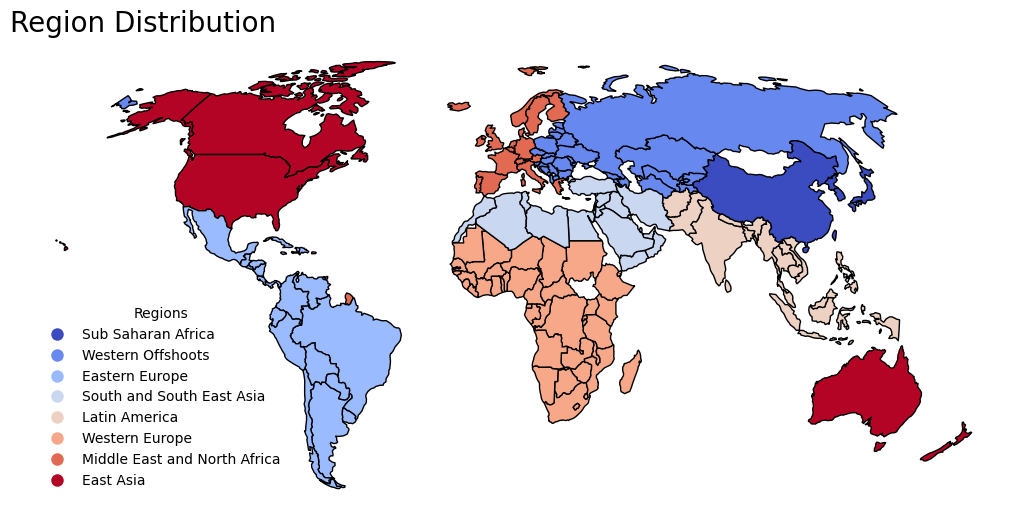

In [63]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# 获取唯一的地区（region）列表
regions = merged_gdppc_region['region'].unique()

# 为每个地区分配颜色
n_regions = len(regions)
colors = plt.get_cmap('coolwarm', n_regions)  # 为每个地区分配颜色

# 创建颜色映射：将 region（字符串）映射到相应的颜色索引
region_color_mapping = {region: colors(i) for i, region in enumerate(regions)}

# 将 regions 列转换为对应的颜色
merged_gdppc_region['region_color'] = merged_gdppc_region['region'].map(region_color_mapping)

# 创建图形和子图
fig_width = 3900 / 300  # 宽度为 1920 像素，300 DPI
fig_height = 2300 / 300  # 高度为 1080 像素，300 DPI

fig, ax = plt.subplots(figsize=(fig_width, fig_height))  # 设置合适的大小

# 使用 coolwarm colormap 进行绘图
merged_gdppc_region.dropna().plot(
    column='region',              # 使用 'region' 列作为绘图数据
    cmap='coolwarm',              # 使用 coolwarm colormap
    ax=ax,                        # 绘制在指定的子图上
    legend=False,                 # 关闭自动图例
    edgecolor='black',            # 设置国家边界为黑色
    missing_kwds={                # 设置没有数据的国家颜色
        "color": "white"          # 将没有数据的国家设置为白色
    }
)

# 隐藏坐标轴上的数值
ax.set_xticks([])  # 隐藏x轴的刻度
ax.set_yticks([])  # 隐藏y轴的刻度
ax.spines[['top', 'right', 'bottom', 'left']].set_visible(False)  # 隐藏四边的轴线

# 创建自定义图例
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=region_color_mapping[region], markersize=10, label=region) for region in regions]
ax.legend(
    handles=handles, 
    title="Regions", 
    loc="lower left",              # 设置图例在图的左下角
    bbox_to_anchor=(0.02, 0.02),   # 调整图例在图内部的位置 (x, y 坐标)
    frameon=False                  # 移除图例框线
)

# 设置标题
title = 'Region Distribution'
ax.set_title(title, fontdict={'fontsize': 20}, loc='left')

# 保存图像为 PNG，300 DPI
plt.savefig('./../Notebooks/Images/World_Map_Region.png', dpi=300, bbox_inches='tight')  # 使用 bbox_inches='tight' 以去除多余空白

# 显示图像
plt.show()
